In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
categories = [
    "rec.sport.baseball",
    "rec.sport.hockey",
    "sci.space",
    "sci.med"
]

data = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

texts = data.data
labels = data.target

print("Number of documents:", len(texts))
print("Number of classes:", len(data.target_names))
print("Classes:", data.target_names)

Number of documents: 3970
Number of classes: 4
Classes: ['rec.sport.baseball', 'rec.sport.hockey', 'sci.med', 'sci.space']


In [3]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(texts)

print("Number of documents:", X.shape[0])
print("Number of words:", X.shape[1])

Number of documents: 3970
Number of words: 5000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training documents:", X_train.shape[0])
print("Testing documents:", X_test.shape[0])

Training documents: 3176
Testing documents: 794


In [5]:
classes = np.unique(y_train)

mle_probabilities = {}

for c in classes:
    class_documents = X_train[y_train == c]
    
    word_counts = np.asarray(class_documents.sum(axis=0)).flatten()
    
    total_words = word_counts.sum()
    
    mle_probabilities[c] = word_counts / total_words

print("MLE parameter estimation completed.")

MLE parameter estimation completed.


In [6]:
for c in classes:
    print("\nClass:", data.target_names[c])
    print("Sum of probabilities:", mle_probabilities[c].sum())


Class: rec.sport.baseball
Sum of probabilities: 1.0

Class: rec.sport.hockey
Sum of probabilities: 1.0

Class: sci.med
Sum of probabilities: 0.9999999999999999

Class: sci.space
Sum of probabilities: 1.0


In [7]:
def calculate_map(X_train, y_train, alpha):
    map_probabilities = {}

    for c in classes:
        class_documents = X_train[y_train == c]
        
        word_counts = np.asarray(
            class_documents.sum(axis=0)
        ).flatten()
        
        total_words = word_counts.sum()
        
        vocabulary_size = len(word_counts)
        
        numerator = word_counts + alpha - 1
        denominator = total_words + vocabulary_size * (alpha - 1)
        
        map_probabilities[c] = numerator / denominator

    return map_probabilities

In [8]:
alphas = [0.5, 1.0, 2.0]

map_results = {}

for alpha in alphas:
    map_results[alpha] = calculate_map(
        X_train,
        y_train,
        alpha
    )

print("MAP estimation completed for:")
print(alphas)

MAP estimation completed for:
[0.5, 1.0, 2.0]


In [9]:
feature_names = np.array(vectorizer.get_feature_names_out())

class_id = classes[0]

mle = mle_probabilities[class_id]

top_indices = np.argsort(mle)[-10:][::-1]

print("Class:", data.target_names[class_id])
print("\nTop words using MLE:")

for i in top_indices:
    print(feature_names[i], ":", mle[i])

Class: rec.sport.baseball

Top words using MLE:
year : 0.009637952559300875
game : 0.008514357053682897
don : 0.007465667915106117
team : 0.006741573033707865
think : 0.00651685393258427
good : 0.005842696629213483
games : 0.0056179775280898875
baseball : 0.005393258426966292
time : 0.005343320848938827
like : 0.005193508114856429


In [10]:
comparison = []

for alpha in alphas:
    probabilities = map_results[alpha][class_id]
    
    top_index = np.argmax(probabilities)
    
    comparison.append({
        "Alpha": alpha,
        "Most Probable Word": feature_names[top_index],
        "Maximum Probability": probabilities[top_index]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Alpha,Most Probable Word,Maximum Probability
0,0.5,year,0.010266
1,1.0,year,0.009638
2,2.0,year,0.008590


In [11]:
selected_words = ["space", "game", "hockey", "medical"]

word_indices = []

for word in selected_words:
    if word in vectorizer.vocabulary_:
        word_indices.append(vectorizer.vocabulary_[word])

class_id = classes[0]

values = []

for index in word_indices:
    row = {
        "Word": feature_names[index],
        "MLE": mle_probabilities[class_id][index]
    }
    
    for alpha in alphas:
        row[f"MAP α={alpha}"] = map_results[alpha][class_id][index]
    
    values.append(row)

comparison_words = pd.DataFrame(values)

comparison_words

,Word,MLE,MAP α=0.5,MAP α=1.0,MAP α=2.0
0,space,0.000050,0.000040,0.000050,0.000067
1,game,0.008514,0.009068,0.008514,0.007592
2,hockey,0.000150,0.000146,0.000150,0.000155
3,medical,0.000025,0.000013,0.000025,0.000044


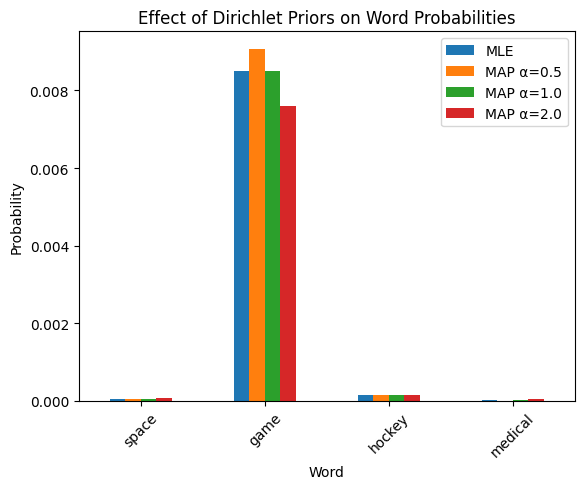

In [12]:
comparison_words.set_index("Word").plot(kind="bar")

plt.title("Effect of Dirichlet Priors on Word Probabilities")
plt.xlabel("Word")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend()
plt.show()